# HW2
Downsampling و Aliasing

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d

%matplotlib inline

IN_DIR = 'Input_Images'
OUT_DIR = 'Output_Images'
os.makedirs(OUT_DIR+'/Part_1', exist_ok=True)
os.makedirs(OUT_DIR+'/Part_2', exist_ok=True)
os.makedirs(OUT_DIR+'/Part_3', exist_ok=True)
os.makedirs(OUT_DIR+'/Part_4', exist_ok=True)

names = ['FerrisWheel.jpg', 'FlyEye.jpg', 'Grid.jpg']
os.listdir(IN_DIR)

['Grid.jpg', 'FlyEye.jpg', 'FerrisWheel.jpg']

In [ ]:
im_test = cv2.imread(IN_DIR + '/FerrisWheel.jpg')
im_test.shape

(467, 350, 3)

In [ ]:
im_test.shape[0]/16 , im_test.shape[1]/16


(29.1875, 21.875)

In [4]:
def load_gray(path):
    bgr = cv2.imread(path)
    g = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    return g.astype(np.uint8)

def crop16(im):
    h,w = im.shape
    h2 = h - h%16
    w2 = w - w%16
    return im[:h2,:w2]

imgs = {}
for n in names:
    g = load_gray(IN_DIR+'/'+n)
    g = crop16(g)
    imgs[n] = g
    print(n, g.shape)

FerrisWheel.jpg (464, 336)
FlyEye.jpg (992, 1488)
Grid.jpg (800, 1200)


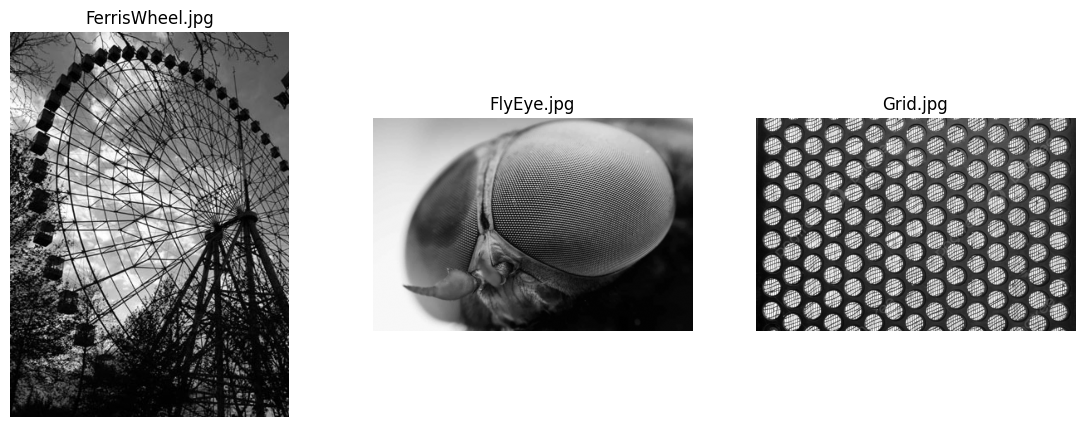

In [5]:
plt.figure(figsize=(14,5))
for i,n in enumerate(names):
    plt.subplot(1,3,i+1)
    plt.imshow(imgs[n], cmap='gray', vmin=0, vmax=255)
    plt.title(n)
    plt.axis('off')
plt.show()


<div dir="rtl" style="text-align: right;">
قسمت ۱ ـ بررسی تصویر در حوزه‌ی فرکانس
</div>

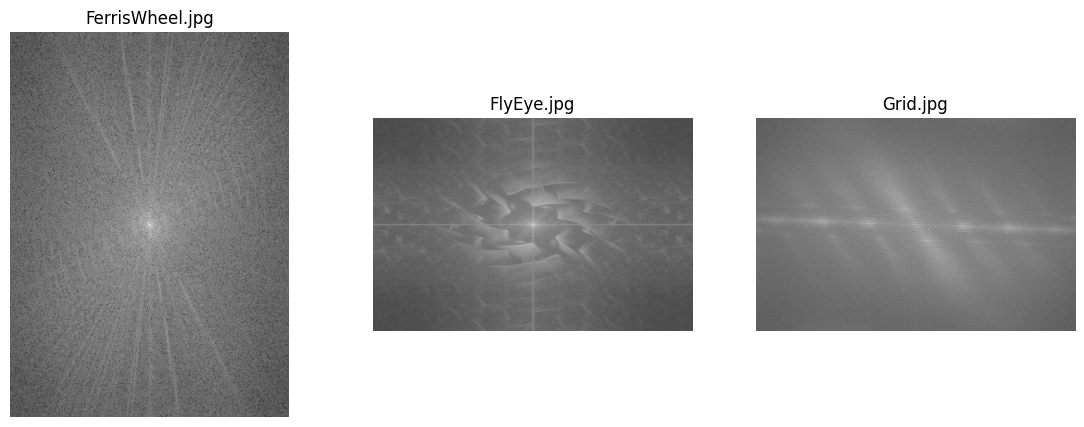

In [6]:
def fft_shift(im):
    F = np.fft.fft2(im.astype(np.float64))
    F = np.fft.fftshift(F)
    return F

def to_show(F):
    m = np.log1p(np.abs(F))
    m = m - m.min()
    m = m/m.max()*255
    return m.astype(np.uint8)

specs = {}
for n in names:
    F = fft_shift(imgs[n])
    specs[n] = F
    out = to_show(F)
    cv2.imwrite(OUT_DIR+'/Part_1/'+n.split('.')[0]+'_spectrum.png', out)

plt.figure(figsize=(14,5))
for i,n in enumerate(names):
    plt.subplot(1,3,i+1)
    plt.imshow(to_show(specs[n]), cmap='gray')
    plt.title(n)
    plt.axis('off')
plt.show()

In [ ]:

def energy_ratio(F, D):
    H,W = F.shape
    hh,ww = H//D, W//D
    cy,cx = H//2, W//2
    mask = np.zeros((H,W), dtype=bool)
    mask[cy-hh//2:cy-hh//2+hh, cx-ww//2:cx-ww//2+ww] = True
    e_in = np.sum(np.abs(F[mask])**2)
    e_out = np.sum(np.abs(F[~mask])**2)
    return e_in, e_out, e_in/e_out

for n in names:
    print(n)
    for D,rate in [(2,4),(4,16)]:
        ein, eout, r = energy_ratio(specs[n], D)
        print('  rate', rate, '->', ein, eout, r)

FerrisWheel.jpg
  rate 4 -> 305239754789448.0 10953392564664.05 27.86714280415366
  rate 16 -> 289445112455101.1 26748034899010.89 10.821172977675621
FlyEye.jpg
  rate 4 -> 4.000772986922865e+16 38748707863442.24 1032.49197393171
  rate 16 -> 3.979519673716845e+16 251281839923637.94 158.36877328366353
Grid.jpg
  rate 4 -> 1.583438979562748e+16 461688138132518.2 34.296722154647476
  rate 16 -> 1.4514468426229176e+16 1781609507530826.5 8.14682923776328



<div dir="rtl" style="text-align: right;">
قسمت ۲ ـ Downsampling بدون Anti-Aliasing Filter
</div>

In [ ]:
def down_plain(im, D):
    return im[::D, ::D]

def up(im, hw, method):
    h,w = hw
    if method=='nearest':
        interp = cv2.INTER_NEAREST
    else:
        interp = cv2.INTER_LINEAR
    return cv2.resize(im, (w,h), interpolation=interp)

res2 = {}
for n in names:
    o = imgs[n]
    H,W = o.shape
    for D,rate in [(2,4),(4,16)]:
        s = down_plain(o, D)
        for m in ['nearest','bilinear']:
            b = up(s, (H,W), m)
            res2[(n,rate,m)] = b
            fn = n.split('.')[0] + '_rate' + str(rate) + '_' + m + '.png'
            cv2.imwrite(OUT_DIR+'/Part_2/'+fn, b)
print('done part 2')

done part 2


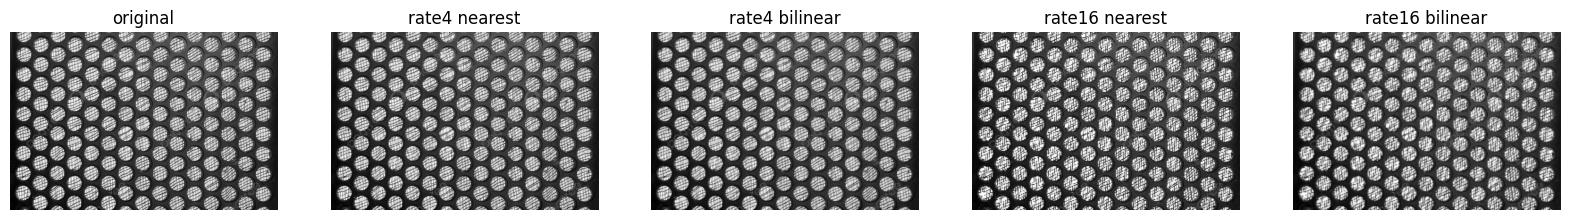

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(1,5,1); plt.imshow(imgs['Grid.jpg'],cmap='gray',vmin=0,vmax=255); plt.title('original'); plt.axis('off')
plt.subplot(1,5,2); plt.imshow(res2[('Grid.jpg',4,'nearest')],cmap='gray',vmin=0,vmax=255); plt.title('rate4 nearest'); plt.axis('off')
plt.subplot(1,5,3); plt.imshow(res2[('Grid.jpg',4,'bilinear')],cmap='gray',vmin=0,vmax=255); plt.title('rate4 bilinear'); plt.axis('off')
plt.subplot(1,5,4); plt.imshow(res2[('Grid.jpg',16,'nearest')],cmap='gray',vmin=0,vmax=255); plt.title('rate16 nearest'); plt.axis('off')
plt.subplot(1,5,5); plt.imshow(res2[('Grid.jpg',16,'bilinear')],cmap='gray',vmin=0,vmax=255); plt.title('rate16 bilinear'); plt.axis('off')
plt.show()


<div dir="rtl" style="text-align: right;">
قسمت ۳ ـ استفاده از فیلتر Anti-Aliasing سه‌تایی
</div>


In [ ]:
k3 = np.array([0.25,0.5,0.25])

def sep_filter(im, k):
    t = convolve1d(im.astype(np.float64), k, axis=0, mode='reflect')
    o = convolve1d(t, k, axis=1, mode='reflect')
    return o


In [11]:
def down_filtered(im, k, n_stage):
    cur = im.astype(np.float64)
    for i in range(n_stage):
        cur = sep_filter(cur, k)
        cur = down_plain(cur, 2)
    return cur

res3 = {}
for n in names:
    o = imgs[n]
    H,W = o.shape
    s4 = down_filtered(o, k3, 1)
    s16 = down_filtered(o, k3, 2)
    for rate, s in [(4,s4),(16,s16)]:
        s = np.clip(s,0,255).astype(np.uint8)
        for m in ['nearest','bilinear']:
            b = up(s, (H,W), m)
            res3[(n,rate,m)] = b
            fn = n.split('.')[0]+'_rate'+str(rate)+'_'+m+'_filter3.png'
            cv2.imwrite(OUT_DIR+'/Part_3/'+fn, b)
print('done part 3')

done part 3


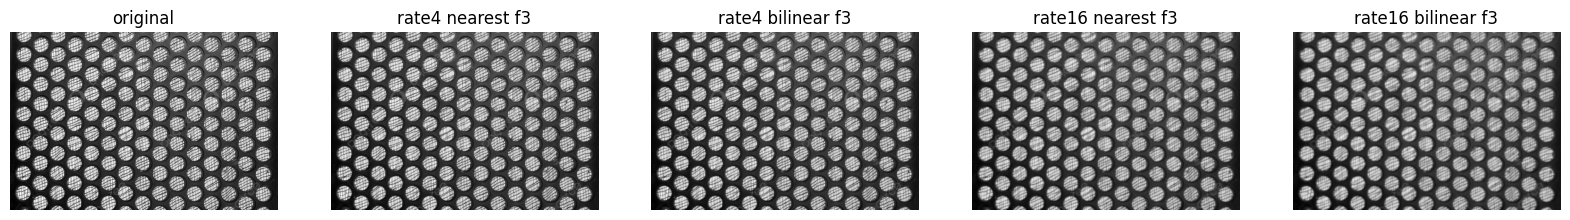

In [12]:
plt.figure(figsize=(20,5))
plt.subplot(1,5,1); plt.imshow(imgs['Grid.jpg'],cmap='gray',vmin=0,vmax=255); plt.title('original'); plt.axis('off')
plt.subplot(1,5,2); plt.imshow(res3[('Grid.jpg',4,'nearest')],cmap='gray',vmin=0,vmax=255); plt.title('rate4 nearest f3'); plt.axis('off')
plt.subplot(1,5,3); plt.imshow(res3[('Grid.jpg',4,'bilinear')],cmap='gray',vmin=0,vmax=255); plt.title('rate4 bilinear f3'); plt.axis('off')
plt.subplot(1,5,4); plt.imshow(res3[('Grid.jpg',16,'nearest')],cmap='gray',vmin=0,vmax=255); plt.title('rate16 nearest f3'); plt.axis('off')
plt.subplot(1,5,5); plt.imshow(res3[('Grid.jpg',16,'bilinear')],cmap='gray',vmin=0,vmax=255); plt.title('rate16 bilinear f3'); plt.axis('off')
plt.show()


<div dir="rtl" style="text-align: right;">
قسمت ۴ ـ فیلتر Anti-Aliasing نه‌تایی
</div>

In [ ]:
k9 = np.array([0.0267,-0.0169,-0.0782,0.2669,0.6029,0.2669,-0.0782,-0.0169,0.0267])
k9.sum()  

np.float64(0.9999)

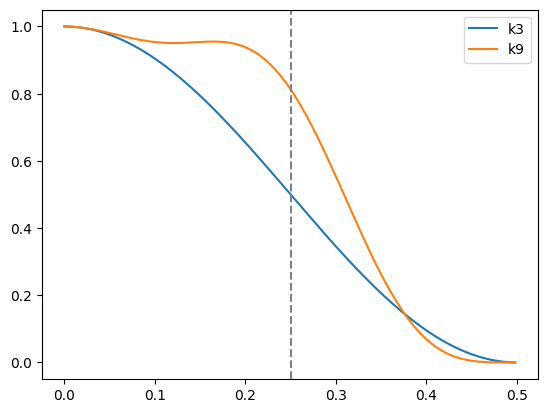

In [ ]:
N = 512
w3 = np.abs(np.fft.fft(k3, N))
w9 = np.abs(np.fft.fft(k9, N))
f = np.fft.fftfreq(N)
plt.plot(f[:N//2], w3[:N//2], label='k3')
plt.plot(f[:N//2], w9[:N//2], label='k9')
plt.axvline(0.25, linestyle='--', color='gray')
plt.legend()
plt.show()


In [15]:
res4 = {}
for n in names:
    o = imgs[n]
    H,W = o.shape
    s4 = down_filtered(o, k9, 1)
    s16 = down_filtered(o, k9, 2)
    for rate, s in [(4,s4),(16,s16)]:
        s = np.clip(s,0,255).astype(np.uint8)
        for m in ['nearest','bilinear']:
            b = up(s, (H,W), m)
            res4[(n,rate,m)] = b
            fn = n.split('.')[0]+'_rate'+str(rate)+'_'+m+'_filter9.png'
            cv2.imwrite(OUT_DIR+'/Part_4/'+fn, b)
print('done part 4')

done part 4


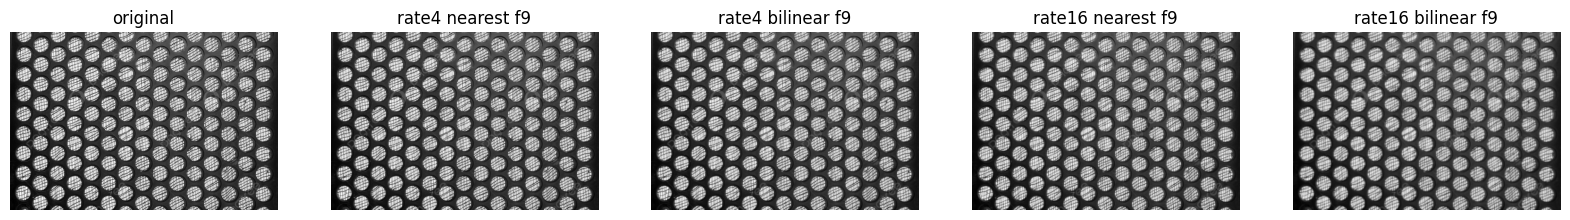

In [16]:
plt.figure(figsize=(20,5))
plt.subplot(1,5,1); plt.imshow(imgs['Grid.jpg'],cmap='gray',vmin=0,vmax=255); plt.title('original'); plt.axis('off')
plt.subplot(1,5,2); plt.imshow(res4[('Grid.jpg',4,'nearest')],cmap='gray',vmin=0,vmax=255); plt.title('rate4 nearest f9'); plt.axis('off')
plt.subplot(1,5,3); plt.imshow(res4[('Grid.jpg',4,'bilinear')],cmap='gray',vmin=0,vmax=255); plt.title('rate4 bilinear f9'); plt.axis('off')
plt.subplot(1,5,4); plt.imshow(res4[('Grid.jpg',16,'nearest')],cmap='gray',vmin=0,vmax=255); plt.title('rate16 nearest f9'); plt.axis('off')
plt.subplot(1,5,5); plt.imshow(res4[('Grid.jpg',16,'bilinear')],cmap='gray',vmin=0,vmax=255); plt.title('rate16 bilinear f9'); plt.axis('off')
plt.show()